In [ ]:

import numpy as np
print("NumPy:", np.__version__)
assert int(np.__version__.split(".")[0]) < 2, "Still NumPy 2.x — restart kernel again"

import os, cv2, time, yaml, random
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from ultralytics import YOLO
import kagglehub
import timm

assert torch.cuda.is_available(), "No GPU found! Runtime → Change runtime type → GPU"
DEVICE = "cuda:0"
print(f"NumPy  : {np.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"GPU    : {torch.cuda.get_device_name(0)}")
print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

torch.backends.cudnn.benchmark = True
torch.backends.cudnn.enabled   = True
print("All imports successful!")

NumPy: 1.26.4
NumPy  : 1.26.4
PyTorch: 2.5.1+cu121
GPU    : NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM   : 6.4 GB
All imports successful!


In [ ]:

import os

cache_dir = os.path.expanduser("~/.cache/kagglehub/datasets/lywang777/urpc2020")

if os.path.exists(cache_dir) and os.listdir(cache_dir):
    versions = sorted(os.listdir(cache_dir))
    path = os.path.join(cache_dir, versions[-1])
    print(f"Using cached dataset (no re-download): {path}")
else:
    path = kagglehub.dataset_download("lywang777/urpc2020")
    print("Downloaded:", path)

print("Dataset Path:", path)
base_path = os.path.join(path, "URPC2020")
print("Base Path   :", base_path)

Using cached dataset (no re-download): C:\Users\pb875/.cache/kagglehub/datasets/lywang777/urpc2020\versions
Dataset Path: C:\Users\pb875/.cache/kagglehub/datasets/lywang777/urpc2020\versions
Base Path   : C:\Users\pb875/.cache/kagglehub/datasets/lywang777/urpc2020\versions\URPC2020


In [ ]:
import yaml
import os


def find_file(root, filename):
    for dirpath, dirnames, filenames in os.walk(root):
        if filename in filenames:
            return dirpath
    return None

dataset_root = find_file(path, "data.yaml")
print("Found dataset root:", dataset_root)

yaml_path = os.path.join(dataset_root, "data.yaml")

with open(yaml_path) as f:
    data = yaml.safe_load(f)

base_dataset_path = dataset_root
data['path']  = base_dataset_path
data['train'] = os.path.join(base_dataset_path, "train/images")
data['val']   = os.path.join(base_dataset_path, "valid/images")
data['test']  = os.path.join(base_dataset_path, "test/images")

with open("data.yaml", "w") as f:
    yaml.dump(data, f)


base_path = dataset_root
print("data.yaml written")
print("   base_path:", base_path)
print("   Classes  :", data.get("names"))


Found dataset root: C:\Users\pb875/.cache/kagglehub/datasets/lywang777/urpc2020\versions\1\URPC2020
data.yaml written
   base_path: C:\Users\pb875/.cache/kagglehub/datasets/lywang777/urpc2020\versions\1\URPC2020
   Classes  : ['holothurian', 'echinus', 'scallop', 'starfish']


In [ ]:

base_path         = dataset_root
base_dataset_path = dataset_root

print("base_path set:", base_path)


for split in ["train", "valid", "test"]:
    img_dir = os.path.join(base_path, split, "images")
    lbl_dir = os.path.join(base_path, split, "labels")
    n_imgs  = len(os.listdir(img_dir)) if os.path.exists(img_dir) else 0
    n_lbls  = len(os.listdir(lbl_dir)) if os.path.exists(lbl_dir) else 0
    print(f"  {split:6s} → {n_imgs} images | {n_lbls} labels")

base_path set: C:\Users\pb875/.cache/kagglehub/datasets/lywang777/urpc2020\versions\1\URPC2020
  train  → 5543 images | 5543 labels
  valid  → 1200 images | 1200 labels
  test   → 800 images | 800 labels


In [ ]:
import os
import cv2
import torch
import numpy as np
from tqdm.notebook import tqdm
from concurrent.futures import ThreadPoolExecutor

base_path = dataset_root

def preprocess_image_gpu(img):
    wb = cv2.xphoto.createSimpleWB()
    img = wb.balanceWhite(img)
    img = cv2.GaussianBlur(img, (3, 3), 0)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    img = cv2.merge((cl, a, b))
    img = cv2.cvtColor(img, cv2.COLOR_LAB2BGR)

    tensor = torch.from_numpy(img).permute(2, 0, 1).float().unsqueeze(0).to(DEVICE) / 255.0
    tensor = torch.clamp(tensor, 0, 1)
    img = (tensor.squeeze(0).permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
    return img

def process_single(img_path):
    img = cv2.imread(img_path)
    if img is None:
        return
    processed = preprocess_image_gpu(img)
    cv2.imwrite(img_path, processed)

def process_folder(folder):
    print(f"Processing images in: {folder}")
    img_paths = [os.path.join(folder, f) for f in os.listdir(folder)]
    with ThreadPoolExecutor(max_workers=8) as executor:
        list(tqdm(executor.map(process_single, img_paths), total=len(img_paths), desc=os.path.basename(folder)))

torch.cuda.empty_cache()
for split in ["train", "valid", "test"]:
    process_folder(os.path.join(base_path, split, "images"))
torch.cuda.empty_cache()

print("Preprocessing Done ")
print(f"GPU Memory Used: {torch.cuda.memory_allocated(0)/1e9:.2f} GB")

Processing images in: C:\Users\pb875/.cache/kagglehub/datasets/lywang777/urpc2020\versions\1\URPC2020\train\images


images:   0%|          | 0/5543 [00:00<?, ?it/s]

Processing images in: C:\Users\pb875/.cache/kagglehub/datasets/lywang777/urpc2020\versions\1\URPC2020\valid\images


images:   0%|          | 0/1200 [00:00<?, ?it/s]

Processing images in: C:\Users\pb875/.cache/kagglehub/datasets/lywang777/urpc2020\versions\1\URPC2020\test\images


images:   0%|          | 0/800 [00:00<?, ?it/s]

Preprocessing Done ✅
GPU Memory Used: 0.00 GB


In [ ]:
class ECAModule(nn.Module):
    def __init__(self, channels, k_size=3):
        super(ECAModule, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=k_size, padding=(k_size-1)//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        y = self.avg_pool(x)
        y = self.conv(y.squeeze(-1).transpose(-1, -2))
        y = self.sigmoid(y).transpose(-1, -2).unsqueeze(-1)
        return x * y.expand_as(x)

print("ECAModule defined")

ECAModule defined


In [ ]:
import timm

class MobileNetV3_ECA(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model('mobilenetv3_small_100', pretrained=True, features_only=True)
        self.eca = ECAModule(576)

    def forward(self, x):
        features = self.backbone(x)
        x = features[-1]
        x = self.eca(x)
        return x

backbone_model = MobileNetV3_ECA().to(DEVICE)
backbone_model.eval()

with torch.no_grad():
    dummy = torch.randn(1, 3, 640, 640).to(DEVICE)
    out = backbone_model(dummy)
    print("Backbone output shape:", out.shape)
    print("Backbone on:", next(backbone_model.parameters()).device)
    print("GPU Memory Used:", round(torch.cuda.memory_allocated(0)/1e9, 2), "GB")

Unexpected keys (classifier.bias, classifier.weight, conv_head.bias, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Backbone output shape: torch.Size([1, 576, 20, 20])
Backbone on: cuda:0
GPU Memory Used: 0.01 GB


In [ ]:
model = YOLO("yolov8n.pt")
print("YOLOv8n loaded")

YOLOv8n loaded


In [ ]:
model.train(
    data="data.yaml",
    epochs=30,
    imgsz=640,
    batch=32,
    device=0,
    amp=True,
    cache=True,
    workers=4,
    optimizer="AdamW",
    lr0=0.001,
    lrf=0.01,
    cos_lr=True,
    warmup_epochs=3,
    mosaic=1.0,
    mixup=0.15,
    close_mosaic=15,
    hsv_h=0.015,
    hsv_s=0.5,
    hsv_v=0.4,
    fliplr=0.5,
    flipud=0.1,
    scale=0.5,
    translate=0.1,
    degrees=5.0,
    patience=30,
    save_period=10,
    plots=True,
    project="runs/detect",
    name="urpc_optimized",
    exist_ok=True,
)

print(" Training Complete")

New https://pypi.org/project/ultralytics/8.4.32 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.204  Python-3.12.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=15, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=urpc_optimized, nbs=64, nms=False,

In [ ]:
metrics = model.val()
print(metrics)

Ultralytics 8.3.204  Python-3.12.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
Model summary (fused): 72 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 926.6110.8 MB/s, size: 2768.6 KB)
val: Scanning C:\Users\pb875\.cache\kagglehub\datasets\lywang777\urpc2020\versions\1\URPC2020\valid\labels.cache... 1200 images, 47 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1200/1200  0.0s
WARNING cache='ram' may produce non-deterministic training results. Consider cache='disk' as a deterministic alternative if your disk space allows.
val: Caching images (0.8GB RAM): 100% ━━━━━━━━━━━━ 1200/1200 59.5it/s 20.2s<0.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 3.1it/s 12.4s0.3s
                   all       1200       9390      0.742       0.58      0.649      0.344
           holothurian        255        461      0.686      0.493      0.542      0.292

In [ ]:
results = model.predict(
    source=os.path.join(base_path, "test/images"),
    save=True,
    conf=0.25
)


image 1/800 C:\Users\pb875\.cache\kagglehub\datasets\lywang777\urpc2020\versions\1\URPC2020\test\images\000001.jpg: 384x640 3 holothurians, 6 echinuss, 363.3ms
image 2/800 C:\Users\pb875\.cache\kagglehub\datasets\lywang777\urpc2020\versions\1\URPC2020\test\images\000002.jpg: 384x640 1 holothurian, 6 echinuss, 1 starfish, 11.5ms
image 3/800 C:\Users\pb875\.cache\kagglehub\datasets\lywang777\urpc2020\versions\1\URPC2020\test\images\000003.jpg: 384x640 2 holothurians, 1 echinus, 15.7ms
image 4/800 C:\Users\pb875\.cache\kagglehub\datasets\lywang777\urpc2020\versions\1\URPC2020\test\images\000004.jpg: 384x640 1 holothurian, 2 echinuss, 1 starfish, 10.2ms
image 5/800 C:\Users\pb875\.cache\kagglehub\datasets\lywang777\urpc2020\versions\1\URPC2020\test\images\000005.jpg: 384x640 1 holothurian, 4 echinuss, 10.6ms
image 6/800 C:\Users\pb875\.cache\kagglehub\datasets\lywang777\urpc2020\versions\1\URPC2020\test\images\000006.jpg: 384x640 1 holothurian, 2 echinuss, 10.2ms
image 7/800 C:\Users\pb87

In [ ]:
import time

img = os.path.join(base_path, "test/images")
start = time.time()
model.predict(img)
end = time.time()

print("FPS:", 1/(end-start))


image 1/800 C:\Users\pb875\.cache\kagglehub\datasets\lywang777\urpc2020\versions\1\URPC2020\test\images\000001.jpg: 384x640 3 holothurians, 6 echinuss, 69.8ms
image 2/800 C:\Users\pb875\.cache\kagglehub\datasets\lywang777\urpc2020\versions\1\URPC2020\test\images\000002.jpg: 384x640 1 holothurian, 6 echinuss, 1 starfish, 41.2ms
image 3/800 C:\Users\pb875\.cache\kagglehub\datasets\lywang777\urpc2020\versions\1\URPC2020\test\images\000003.jpg: 384x640 2 holothurians, 1 echinus, 40.6ms
image 4/800 C:\Users\pb875\.cache\kagglehub\datasets\lywang777\urpc2020\versions\1\URPC2020\test\images\000004.jpg: 384x640 1 holothurian, 2 echinuss, 1 starfish, 40.8ms
image 5/800 C:\Users\pb875\.cache\kagglehub\datasets\lywang777\urpc2020\versions\1\URPC2020\test\images\000005.jpg: 384x640 1 holothurian, 4 echinuss, 39.7ms
image 6/800 C:\Users\pb875\.cache\kagglehub\datasets\lywang777\urpc2020\versions\1\URPC2020\test\images\000006.jpg: 384x640 1 holothurian, 2 echinuss, 39.4ms
image 7/800 C:\Users\pb875

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\core\src\alloc.cpp:73: error: (-4:Insufficient memory) Failed to allocate 24883200 bytes in function 'cv::OutOfMemoryError'


In [ ]:
import os
import random
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO


model = YOLO("runs/detect/train/weights/best.pt")


test_path = os.path.join(base_path, "test/images")


image_list = random.sample(os.listdir(test_path), 4)

plt.figure(figsize=(12,10))

for i, img_name in enumerate(image_list):
    img_path = os.path.join(test_path, img_name)


    results = model.predict(
        source=img_path,
        conf=0.25,
        save=False
    )


    plotted_img = results[0].plot()

    plotted_img = cv2.cvtColor(plotted_img, cv2.COLOR_BGR2RGB)


    plt.subplot(2, 2, i+1)
    plt.imshow(plotted_img)
    plt.title(f"Detection {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 824.0/824.0 kB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 34.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 23.9 MB/s eta 0:00:00


 Loading model: /content/best (1).pt
Please upload your test images (.jpg, .png, etc.):


Saving 000784.jpg to 000784.jpg

Processing 1 images...


image 1/1 /content/000784.jpg: 192x320 5 echinuss, 1 starfish, 57.2ms
Speed: 0.7ms preprocess, 57.2ms inference, 0.9ms postprocess per image at shape (1, 3, 192, 320)


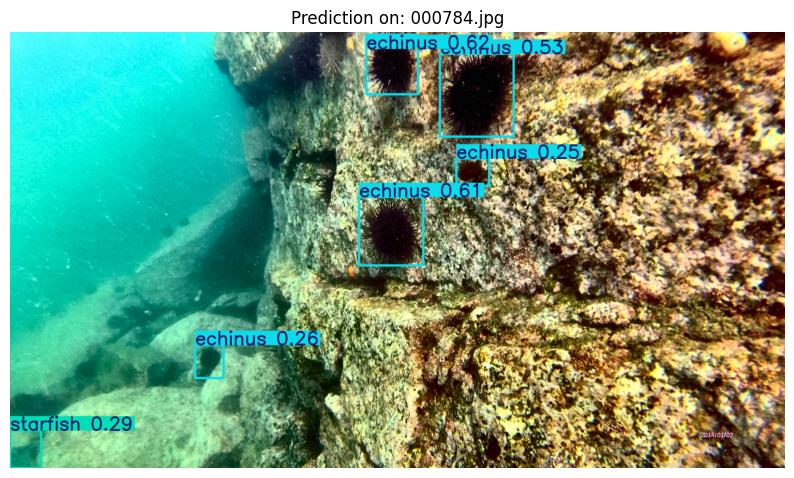

In [ ]:

!pip install ultralytics

import os
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import files


!pip install opencv-python-headless

import cv2

EXP17_MODEL_PATH = "/content/best (1).pt"

if not os.path.exists(EXP17_MODEL_PATH):
    print(f" Model not found at: {EXP17_MODEL_PATH}")
else:

    print(f" Loading model: {EXP17_MODEL_PATH}")
    model_exp17 = YOLO(EXP17_MODEL_PATH)


    print("Please upload your test images (.jpg, .png, etc.):")
    uploaded = files.upload()

    if uploaded:
        print(f"\nProcessing {len(uploaded)} images...\n")
        for filename in uploaded.keys():

            results = model_exp17.predict(source=filename, conf=0.25, save=False)


            plotted_img = results[0].plot()
            plotted_img_rgb = cv2.cvtColor(plotted_img, cv2.COLOR_BGR2RGB)

            plt.figure(figsize=(10, 8))
            plt.imshow(plotted_img_rgb)
            plt.title(f"Prediction on: {filename}")
            plt.axis('off')
            plt.show()
    else:
        print("No files uploaded.")